In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('loan_approval_dataset.csv.xls')

In [3]:
x = df.drop(columns='Loan_Approved')
y=df.Loan_Approved

In [4]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [5]:
x.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [6]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_13116\4193232358.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols=x.select_dtypes(include='object').columns


<Axes: >

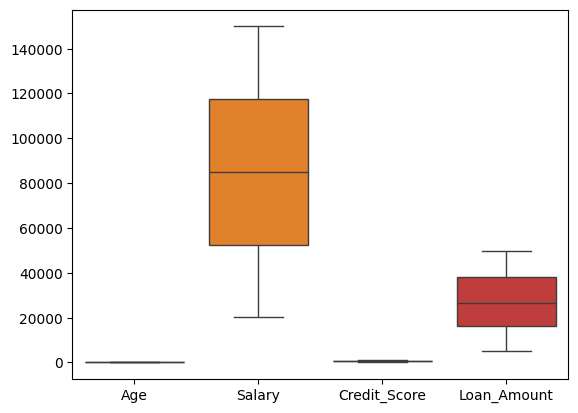

In [7]:
sns.boxplot(x[num_cols])

In [8]:
'''
preprocessing techniques:
-scaling
-Encoding

why scaling?
feature col values are in diferent range(scale) so we can use scaling to give equal imp to all features cols

why encoding?
alg can only understand only num not string

which scaling and encoding techniques can be used?
scaling-minmaxscaler,standardscaler
encoding-onehotencoder(less unique values)
Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64





'''


'\npreprocessing techniques:\n-scaling\n-Encoding\n\nwhy scaling?\nfeature col values are in diferent range(scale) so we can use scaling to give equal imp to all features cols\n\nwhy encoding?\nalg can only understand only num not string\n\nwhich scaling and encoding techniques can be used?\nscaling-minmaxscaler,standardscaler\nencoding-onehotencoder(less unique values)\nLoan_Term            4\nEmployment_Status    3\nResidence_Type       3\nPrevious_Default     2\ndtype: int64\n\n\n\n\n\n'

In [9]:
x[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

In [10]:
encoder=OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)
scaling=MinMaxScaler()
#model=LogisticRegression(penalty='l1',solver='liblinear')
model=LogisticRegression(penalty=None)

In [11]:
# model.fit(xtrain,ytrain)

In [12]:
#xtrain

xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
# xtrain[obj_cols]=scaling.fit_transform(xtrain[obj_cols])
encoded_values=encoder.fit_transform(xtrain[obj_cols])
encoded_columns=encoder.get_feature_names_out()

xtrain[encoded_columns]=encoded_values
xtrain.drop(columns=obj_cols,inplace=True)


In [13]:
#update xtest
xtest[num_cols] = scaling.transform(xtest[num_cols])
encoded_values=encoder.transform(xtest[obj_cols])
xtest[encoded_columns]=encoded_values
xtest.drop(columns=obj_cols,inplace=True)



In [14]:
model.fit(xtrain,ytrain)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [15]:
#Evaluation
model.score(xtrain,ytrain)


0.54625

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix, f1_score 

# Train Data Evaluation

In [17]:
ytrain_pred=model.predict(xtrain)
confusion_matrix(ytrain,ytrain_pred)

array([[205, 192],
       [171, 232]])

In [18]:
y.value_counts()

Loan_Approved
Yes    508
No     492
Name: count, dtype: int64

In [19]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

In [20]:
matrix = confusion_matrix(ytrain, ytrain_pred, labels=['Yes', 'No'])

In [21]:
matrix = confusion_matrix(ytrain, ytrain_pred, labels=['Yes', 'No'])
predicted_yes = np.sum(matrix[:, 0])
predicted_no = np.sum(matrix[:, 1])

Conclusion :

-Out of all the predicted `Yes` labels(425),54% labels are correctly predicted as `Yes`

- Out of all the predicted `Yes` labels(425),46% labels are wrongly  predicted as `Yes`

In [22]:
precision_score(ytrain,ytrain_pred,pos_label='No')

0.5452127659574468

Conclusion :

-Out of all the predicted `No` labels(375),54% labels are correctly predicted as `No`

- Out of all the predicted `No` labels(375),46% labels are wrongly  predicted as `No`

In [23]:
recall_score(ytrain,ytrain_pred,pos_label='Yes')

0.575682382133995

Conclusion :

-Out of all the actual `Yes` labels(403),57% labels are correctly predicted as `Yes`

- Out of all the actual `Yes` labels(403),43% labels are wrongly  predicted as `No`

In [24]:
recall_score(ytrain,ytrain_pred,pos_label='No')

0.5163727959697733

Conclusion :

-Out of all the actual `No` labels(397),51% labels are correctly predicted as `No`

- Out of all the actual `No` labels(397),49% labels are wrongly  predicted as `Yes`

In [25]:
accuracy_score(ytrain,ytrain_pred)

0.54625

Conclusion :

Out of all the samples(800),54.75% samples are correctly predicted

Final Conclusion :

Model performance on train data is bad,so model is not learned train data patterns properly

In [26]:
accuracy_score(ytest,ytest)

1.0

In [27]:
ypred_test=model.predict(xtest)

In [28]:
accuracy_score(ytest,ypred_test)

0.5


## Classification Report 

8 july

'''From classification report provides all the metrices'''

In [29]:
from sklearn.metrics import classification_report

In [30]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



Macro is a  very important metric.

In [31]:
print(classification_report(ytest,ypred_test))

              precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200

